# Data Pipeline & Exploratory Analysis

Analyzing southern pine forest growth using USDA Forest Inventory & Analysis (FIA) public data across Georgia (GA), Alabama (AL), and South Carolina (SC).

**Run this notebook from the `notebooks/` directory.**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Southern pine species (USDA FIA species codes, all ModRel=1)
# Source: FIA Species Code reference list
SOUTHERN_PINE_SPECIES = {
    110: "Shortleaf pine",   # Pinus echinata
    111: "Slash pine",       # Pinus elliottii
    121: "Longleaf pine",    # Pinus palustris
    131: "Loblolly pine",    # Pinus taeda
}

STATES = ["GA", "AL", "SC"]
TABLES = ["TREE", "PLOT", "COND"]

DATA_DIR = "../data"
OUTPUTS_DIR = "../outputs"

## 1. Load Raw Data

In [2]:
TREE_COLS = ["CN", "PLT_CN", "CONDID", "SPCD", "STATUSCD", "DIA", "PREVDIA", "INVYR"]
PLOT_COLS = ["CN", "LAT", "LON", "ELEV", "REMPER", "MEASYEAR"]
COND_COLS = ["PLT_CN", "CONDID", "STDAGE"]

tree_frames, plot_frames, cond_frames = [], [], []

for state in STATES:
    tree_frames.append(pd.read_csv(os.path.join(DATA_DIR, f"{state}_TREE.csv"), usecols=TREE_COLS).assign(state=state))
    plot_frames.append(pd.read_csv(os.path.join(DATA_DIR, f"{state}_PLOT.csv"), usecols=PLOT_COLS).assign(state=state))
    cond_frames.append(pd.read_csv(os.path.join(DATA_DIR, f"{state}_COND.csv"), usecols=COND_COLS).assign(state=state))

print("Files read.")

Files read.


In [3]:
tree = pd.concat(tree_frames, ignore_index=True)
plot = pd.concat(plot_frames, ignore_index=True)
cond = pd.concat(cond_frames, ignore_index=True)

for name, df in [("TREE", tree), ("PLOT", plot), ("COND", cond)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

tree.head()

TREE: 4,177,453 rows x 9 columns
PLOT: 161,563 rows x 7 columns
COND: 199,699 rows x 4 columns


,CN,PLT_CN,INVYR,CONDID,STATUSCD,SPCD,DIA,PREVDIA,state
0,158870927010854,158712463010854,1972,1,1,111.0,4.6,NaN,GA
1,158870928010854,158712463010854,1972,1,1,131.0,10.9,NaN,GA
2,158870929010854,158712463010854,1972,1,1,111.0,7.9,NaN,GA
3,158870930010854,158712463010854,1972,1,1,111.0,8.1,NaN,GA
4,158870931010854,158712463010854,1972,1,1,111.0,4.3,NaN,GA


In [4]:
for name, df in [("TREE", tree), ("PLOT", plot), ("COND", cond)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

for name, df in [("TREE", tree), ("PLOT", plot), ("COND", cond)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(df.head())


TREE: 4,177,453 rows x 9 columns
PLOT: 161,563 rows x 7 columns
COND: 199,699 rows x 4 columns
TREE: 4,177,453 rows x 9 columns


,CN,PLT_CN,INVYR,CONDID,STATUSCD,SPCD,DIA,PREVDIA,state
0,158870927010854,158712463010854,1972,1,1,111.0,4.6,NaN,GA
1,158870928010854,158712463010854,1972,1,1,131.0,10.9,NaN,GA
2,158870929010854,158712463010854,1972,1,1,111.0,7.9,NaN,GA
3,158870930010854,158712463010854,1972,1,1,111.0,8.1,NaN,GA
4,158870931010854,158712463010854,1972,1,1,111.0,4.3,NaN,GA


PLOT: 161,563 rows x 7 columns


,CN,MEASYEAR,REMPER,LAT,LON,ELEV,state
0,76355732010478,2005.0,3.8,32.657528,-82.315483,280,GA
1,76355989010478,2005.0,5.9,32.056778,-81.835922,150,GA
2,76356069010478,2005.0,4.1,34.860071,-84.457850,2660,GA
3,76356282010478,2005.0,4.0,34.840699,-84.312903,2120,GA
4,76356452010478,2005.0,3.8,34.928583,-84.281292,1760,GA


COND: 199,699 rows x 4 columns


,PLT_CN,CONDID,STDAGE,state
0,158712463010854,1,15.0,GA
1,158712464010854,1,25.0,GA
2,158712465010854,1,35.0,GA
3,158712466010854,1,45.0,GA
4,158712467010854,1,5.0,GA


## 2. Explore TREE Table

In [5]:
# Dtypes and null counts for key columns
key_cols = ["SPCD", "STATUSCD", "DIA", "PREVDIA", "INVYR"]
print(tree[key_cols].dtypes)
print()
print("Null counts:")
print(tree[key_cols].isnull().sum())

SPCD        float64
STATUSCD      int64
DIA         float64
PREVDIA     float64
INVYR         int64
dtype: object

Null counts:
SPCD              0
STATUSCD          0
DIA           69590
PREVDIA     1081803
INVYR             0
dtype: int64


In [6]:
# Inventory years covered
tree["INVYR"].value_counts().sort_index()

INVYR
1968    140184
1972    316680
1978    157639
1982    285309
1986    136259
1989    262128
1990    128280
1993    174979
1997    317258
1998     34944
1999     63045
2000    248293
2001    102794
2002     72367
2003     72794
2004     76245
2005     93700
2006     78012
2007     79088
2008     73306
2009     77729
2010     78284
2011     80785
2012     82297
2013     80411
2014     81820
2015     80179
2016     80402
2017     83110
2018     80257
2019     80445
2020     77614
2021     78047
2022     73529
2023     71876
2024     77364
Name: count, dtype: int64

In [7]:
# Tree status: 1=live, 2=dead, 3=removed
tree["STATUSCD"].value_counts().sort_index()

STATUSCD
0      68935
1    3425672
2     557871
3     124975
Name: count, dtype: int64

In [8]:
# Top species by record count (before filtering)
tree["SPCD"].value_counts().head(20)

SPCD
131.0    1141750
611.0     405567
111.0     268493
316.0     215481
827.0     195150
694.0     179823
110.0     118848
621.0     101949
820.0      88079
802.0      85972
121.0      83535
491.0      77530
812.0      65350
693.0      58657
132.0      57920
400.0      56815
653.0      49908
762.0      46702
835.0      43467
711.0      43100
Name: count, dtype: int64

## 3. Explore PLOT Table

In [9]:
# Dtypes and null counts for key columns
plot_key_cols = ["LAT", "LON", "ELEV", "REMPER", "MEASYEAR"]
print(plot[plot_key_cols].dtypes)
print()
print("Null counts:")
print(plot[plot_key_cols].isnull().sum())

LAT         float64
LON         float64
ELEV          int64
REMPER      float64
MEASYEAR    float64
dtype: object

Null counts:
LAT           202
LON           202
ELEV            0
REMPER      32355
MEASYEAR     2442
dtype: int64


In [10]:
# Remeasurement period distribution — drives annual growth calculation
plot["REMPER"].value_counts().sort_index()

REMPER
0.0     204
0.1       2
0.2       1
0.3       2
0.4       8
       ... 
11.6     56
11.8      1
11.9      2
12.0      1
12.1      1
Name: count, Length: 121, dtype: int64

## 4. Explore COND Table

In [11]:
# Dtypes and null counts
print(cond[["STDAGE"]].dtypes)
print()
print("Null counts:")
print(cond[["STDAGE"]].isnull().sum())

STDAGE    float64
dtype: object

Null counts:
STDAGE    63252
dtype: int64


In [12]:
# Stand age distribution
cond["STDAGE"].describe()

count    136447.000000
mean         35.181316
std          26.439945
min           0.000000
25%          15.000000
50%          30.000000
75%          51.000000
max         184.000000
Name: STDAGE, dtype: float64

## 5. Filter & Join

In [13]:
# Filter TREE: live trees only, southern pine species only
pine_live = tree[
    (tree["STATUSCD"] == 1) &
    (tree["SPCD"].isin(SOUTHERN_PINE_SPECIES.keys()))
].copy()

print(f"TREE raw:           {len(tree):>10,}")
print(f"After status=1:     {len(tree[tree['STATUSCD']==1]):>10,}  ({len(tree)-len(tree[tree['STATUSCD']==1]):,} dropped)")
print(f"After species filter:{len(pine_live):>9,}  ({len(tree[tree['STATUSCD']==1])-len(pine_live):,} dropped)")

TREE raw:            4,177,453
After status=1:      3,425,672  (751,781 dropped)
After species filter:1,271,080  (2,154,592 dropped)


In [14]:
# Inner join TREE → PLOT on PLT_CN
# Rename PLOT.CN → PLT_CN to match the join key; drop redundant state column
plot_for_join = plot.rename(columns={"CN": "PLT_CN"}).drop(columns=["state"])
df = pine_live.merge(plot_for_join, on="PLT_CN", how="inner")

print(f"Before PLOT join:  {len(pine_live):>10,}")
print(f"After PLOT join:   {len(df):>10,}  ({len(pine_live)-len(df):,} dropped)")

Before PLOT join:   1,271,080
After PLOT join:    1,271,080  (0 dropped)


In [15]:
# Inner join → COND on PLT_CN + CONDID
# Drop redundant state column from COND before joining
cond_for_join = cond.drop(columns=["state"])
df = df.merge(cond_for_join, on=["PLT_CN", "CONDID"], how="inner")

print(f"After COND join:   {len(df):>10,}  ({len(pine_live)-len(df):,} total dropped from pine_live)")
print(f"\nFinal columns: {df.columns.tolist()}")
df.head()

After COND join:    1,271,080  (0 total dropped from pine_live)

Final columns: ['CN', 'PLT_CN', 'INVYR', 'CONDID', 'STATUSCD', 'SPCD', 'DIA', 'PREVDIA', 'state', 'MEASYEAR', 'REMPER', 'LAT', 'LON', 'ELEV', 'STDAGE']


,CN,PLT_CN,INVYR,CONDID,STATUSCD,SPCD,DIA,PREVDIA,state,MEASYEAR,REMPER,LAT,LON,ELEV,STDAGE
0,158870927010854,158712463010854,1972,1,1,111.0,4.6,NaN,GA,1971.0,11.0,31.748072,-82.501205,100,15.0
1,158870928010854,158712463010854,1972,1,1,131.0,10.9,NaN,GA,1971.0,11.0,31.748072,-82.501205,100,15.0
2,158870929010854,158712463010854,1972,1,1,111.0,7.9,NaN,GA,1971.0,11.0,31.748072,-82.501205,100,15.0
3,158870930010854,158712463010854,1972,1,1,111.0,8.1,NaN,GA,1971.0,11.0,31.748072,-82.501205,100,15.0
4,158870931010854,158712463010854,1972,1,1,111.0,4.3,NaN,GA,1971.0,11.0,31.748072,-82.501205,100,15.0


## 6. Validate Edge Cases Before Dropping

In [16]:
# PREVDIA null by inventory year — expect concentration in earliest years
print("PREVDIA null count by INVYR:")
print(df[df["PREVDIA"].isnull()]["INVYR"].value_counts().sort_index())
print(df["PREVDIA"].isnull().sum())

PREVDIA null count by INVYR:
INVYR
1968    31917
1972    58649
1978    30618
1982    36015
1986    17924
1989    21781
1993    18534
1998     2162
1999     4965
2000     4942
2001     7265
2002     6225
2003     6774
2004     8872
2005    10885
2006     9743
2007    10063
2008     9297
2009     9710
2010     8775
2011     8912
2012    10041
2013     9971
2014     9715
2015     9053
2016     8873
2017     8269
2018     7804
2019     8395
2020     7440
2021     7009
2022     7577
2023     7087
2024     8203
Name: count, dtype: int64
433465


In [17]:
# REMPER null by measurement year — expect concentration in earliest years (first visits)
print("REMPER null count by MEASYEAR:")
df[df["REMPER"].isnull()]["MEASYEAR"].value_counts().sort_index()

REMPER null count by MEASYEAR:


MEASYEAR
1966.0     448
1967.0    2160
1968.0     810
1970.0     792
1971.0    6396
1972.0    5464
1977.0     125
1978.0     316
1980.0    1511
1981.0    4407
1982.0    3131
1985.0     416
1986.0    1443
1987.0      76
1988.0     895
1989.0     706
1990.0     417
1992.0     528
1993.0     186
1996.0      21
1997.0      11
1998.0      42
1999.0     127
2000.0    2037
2001.0    3645
2002.0    5249
2003.0    5308
2004.0    7213
2005.0    2818
2006.0    1906
2007.0    1452
2008.0     731
2009.0     792
2010.0     839
2011.0     694
2012.0    1452
2013.0    1136
2014.0     972
2015.0     996
2016.0     409
2017.0     190
2018.0      87
2019.0     134
2020.0      97
2021.0     128
2022.0      55
2023.0     103
2024.0     109
2025.0     144
Name: count, dtype: int64

In [18]:
# REMPER = 0 by measurement year — these are valid visits but zero time elapsed
print(f"REMPER = 0 count: {(df['REMPER'] == 0).sum()}")
print("\nBy MEASYEAR:")
df[df["REMPER"] == 0]["MEASYEAR"].value_counts().sort_index()

REMPER = 0 count: 534

By MEASYEAR:


MEASYEAR
1970.0    236
1971.0    150
1972.0    148
Name: count, dtype: int64

## 7. Compute Annual Growth

In [19]:
# Drop rows where growth cannot be computed
print(f"Before dropping:                    {len(df):>10,}")

df_growth = df.dropna(subset=["DIA", "PREVDIA", "REMPER"])
print(f"After dropping null DIA/PREVDIA/REMPER: {len(df_growth):>6,}  ({len(df) - len(df_growth):,} dropped)")

df_growth = df_growth[df_growth["REMPER"] > 0].copy()
print(f"After dropping REMPER=0:            {len(df_growth):>10,}  ({len(df.dropna(subset=['DIA','PREVDIA','REMPER'])) - len(df_growth):,} dropped)")

# Annual diameter growth increment (inches/year)
df_growth["annual_growth"] = (df_growth["DIA"] - df_growth["PREVDIA"]) / df_growth["REMPER"]

# Drop negative growth — physically impossible for live trees (STATUSCD=1), indicates measurement error
before_neg = len(df_growth)
df_growth = df_growth[df_growth["annual_growth"] >= 0]
print(f"After dropping negative growth:     {len(df_growth):>10,}  ({before_neg - len(df_growth):,} dropped)")

print(f"\nGrowth column summary:")
print(df_growth["annual_growth"].describe())

Before dropping:                     1,271,080
After dropping null DIA/PREVDIA/REMPER: 793,335  (477,745 dropped)
After dropping REMPER=0:               793,335  (0 dropped)
After dropping negative growth:        785,988  (7,347 dropped)

Growth column summary:
count    785988.000000
mean          0.188159
std           0.173678
min           0.000000
25%           0.028169
50%           0.166667
75%           0.285714
max           4.722222
Name: annual_growth, dtype: float64


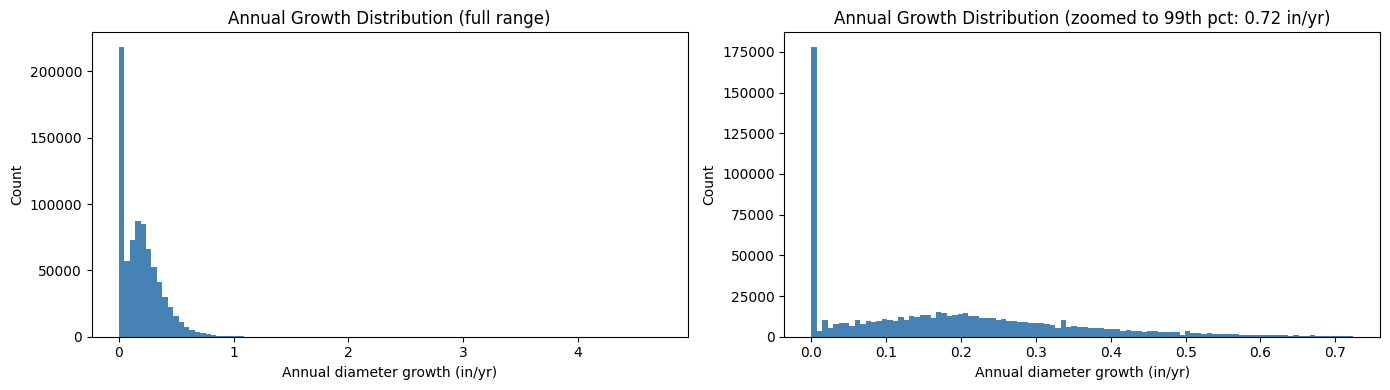


Rows above 99th pct (0.724 in/yr): 7,859


In [20]:
# Growth distribution — full range and zoomed view to understand spread
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(df_growth["annual_growth"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Annual Growth Distribution (full range)")
axes[0].set_xlabel("Annual diameter growth (in/yr)")
axes[0].set_ylabel("Count")

# Zoomed to 99th percentile to see the main body without extreme tail
p99 = df_growth["annual_growth"].quantile(0.99)
axes[1].hist(df_growth[df_growth["annual_growth"] <= p99]["annual_growth"], bins=100, color="steelblue", edgecolor="none")
axes[1].set_title(f"Annual Growth Distribution (zoomed to 99th pct: {p99:.2f} in/yr)")
axes[1].set_xlabel("Annual diameter growth (in/yr)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\nRows above 99th pct ({p99:.3f} in/yr): {(df_growth['annual_growth'] > p99).sum():,}")

In [21]:
# Investigate the near-zero growth spike
near_zero = df_growth[df_growth["annual_growth"] < 0.05]
rest = df_growth[df_growth["annual_growth"] >= 0.05]

print(f"annual_growth < 0.05 in/yr: {len(near_zero):,} ({100*len(near_zero)/len(df_growth):.1f}%)")
print(f"annual_growth >= 0.05 in/yr: {len(rest):,} ({100*len(rest)/len(df_growth):.1f}%)")
print()

# Is the spike driven by long REMPER (slow annual rate from large measurement gaps)?
print("REMPER distribution — near-zero vs rest:")
print(pd.DataFrame({
    "near_zero (<0.05)": near_zero["REMPER"].describe(),
    "rest (>=0.05)":     rest["REMPER"].describe(),
}).round(2))
print()

# Is it driven by tree size? Larger trees grow slower in diameter
print("DIA (current diameter) — near-zero vs rest:")
print(pd.DataFrame({
    "near_zero (<0.05)": near_zero["DIA"].describe(),
    "rest (>=0.05)":     rest["DIA"].describe(),
}).round(2))

annual_growth < 0.05 in/yr: 221,406 (28.2%)
annual_growth >= 0.05 in/yr: 564,582 (71.8%)

REMPER distribution — near-zero vs rest:
       near_zero (<0.05)  rest (>=0.05)
count          221406.00      564582.00
mean                7.87           6.50
std                 1.58           2.15
min                 0.20           0.10
25%                 7.40           5.00
50%                 8.20           6.30
75%                 8.70           8.10
max                12.00          11.80

DIA (current diameter) — near-zero vs rest:
       near_zero (<0.05)  rest (>=0.05)
count          221406.00      564582.00
mean                7.11           9.30
std                 3.53           4.26
min                 1.00           1.00
25%                 5.30           6.70
50%                 6.50           8.70
75%                 8.60          11.60
max                42.00          44.10


## 8. Exploratory Analysis

### 8.1 Growth by State

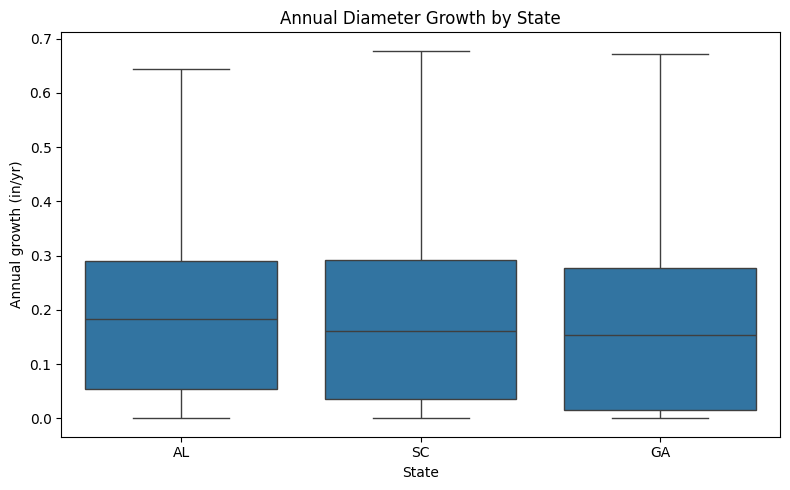

Median annual growth by state:
state
AL    0.184
SC    0.161
GA    0.154
Name: annual_growth, dtype: float64


In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

state_order = df_growth.groupby("state")["annual_growth"].median().sort_values(ascending=False).index
sns.boxplot(data=df_growth, x="state", y="annual_growth", order=state_order,
            showfliers=False, ax=ax)

ax.set_title("Annual Diameter Growth by State")
ax.set_xlabel("State")
ax.set_ylabel("Annual growth (in/yr)")
plt.tight_layout()
plt.show()

print("Median annual growth by state:")
print(df_growth.groupby("state")["annual_growth"].median().sort_values(ascending=False).round(3))

### 8.2 Growth by Species

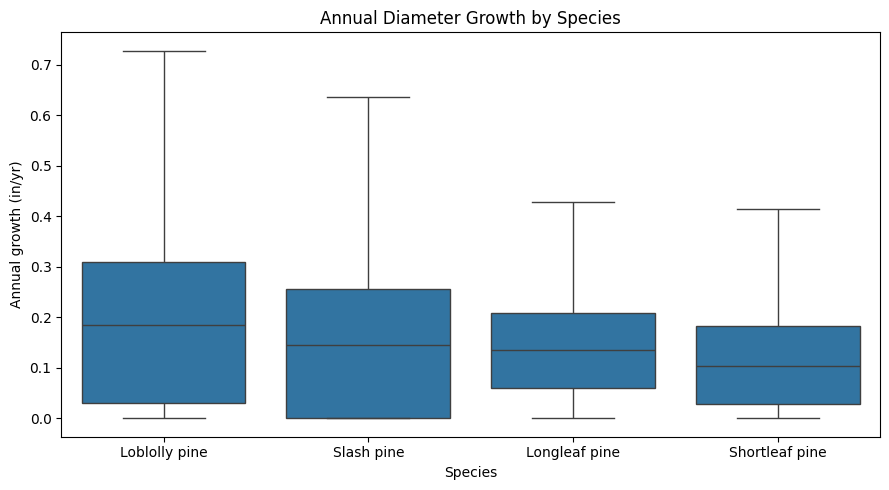

Median annual growth by species:
                 count  median
species_name                  
Loblolly pine   555089   0.185
Slash pine      130592   0.145
Longleaf pine    43176   0.136
Shortleaf pine   57131   0.103


In [23]:
df_growth["species_name"] = df_growth["SPCD"].map(SOUTHERN_PINE_SPECIES)

fig, ax = plt.subplots(figsize=(9, 5))

species_order = df_growth.groupby("species_name")["annual_growth"].median().sort_values(ascending=False).index
sns.boxplot(data=df_growth, x="species_name", y="annual_growth", order=species_order,
            showfliers=False, ax=ax)

ax.set_title("Annual Diameter Growth by Species")
ax.set_xlabel("Species")
ax.set_ylabel("Annual growth (in/yr)")
plt.tight_layout()
plt.show()

print("Median annual growth by species:")
print(df_growth.groupby("species_name")["annual_growth"].agg(["count", "median"]).sort_values("median", ascending=False).round(3))

### 8.3 Growth vs Stand Age

Rows with STDAGE: 784,647 (99.8% of growth dataset)


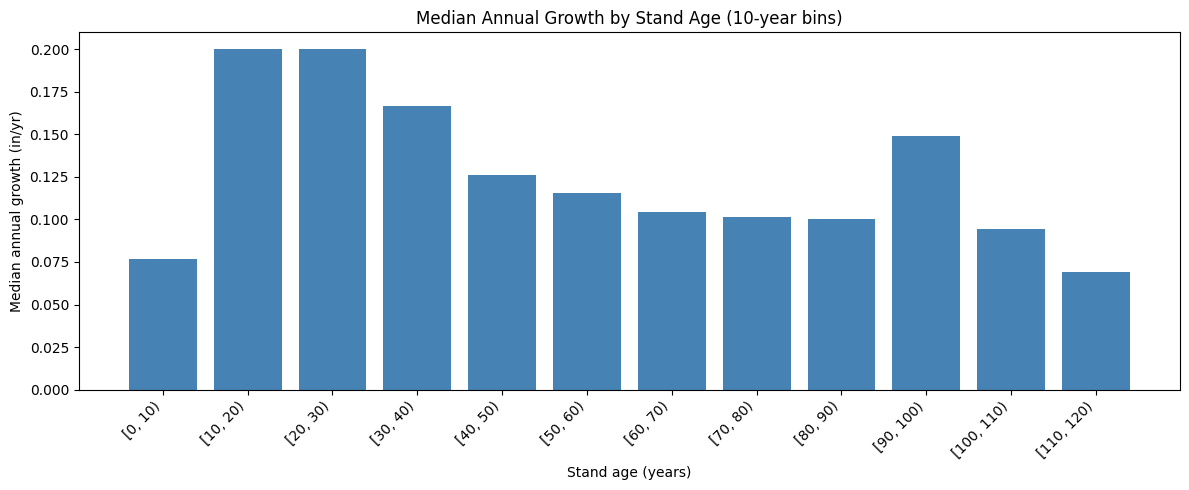


Median growth and record count by stand age bin:
   age_bin   median  count
   [0, 10) 0.076923  42362
  [10, 20) 0.200000 220406
  [20, 30) 0.200000 228363
  [30, 40) 0.166667 121043
  [40, 50) 0.126214  72915
  [50, 60) 0.115385  45008
  [60, 70) 0.104478  27195
  [70, 80) 0.101695  12963
  [80, 90) 0.100000   5617
 [90, 100) 0.148936   7681
[100, 110) 0.094118    592
[110, 120) 0.068966    281


In [24]:
# Only rows with known stand age
df_age = df_growth.dropna(subset=["STDAGE"])
print(f"Rows with STDAGE: {len(df_age):,} ({100*len(df_age)/len(df_growth):.1f}% of growth dataset)")

# Bin stand age into 10-year brackets and compute median growth per bin
df_age = df_age.copy()
df_age["age_bin"] = pd.cut(df_age["STDAGE"], bins=range(0, 121, 10), right=False)
age_summary = df_age.groupby("age_bin", observed=True)["annual_growth"].agg(["median", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(age_summary)), age_summary["median"], color="steelblue", edgecolor="none")
ax.set_xticks(range(len(age_summary)))
ax.set_xticklabels([str(b) for b in age_summary["age_bin"]], rotation=45, ha="right")
ax.set_title("Median Annual Growth by Stand Age (10-year bins)")
ax.set_xlabel("Stand age (years)")
ax.set_ylabel("Median annual growth (in/yr)")
plt.tight_layout()
plt.show()

print("\nMedian growth and record count by stand age bin:")
print(age_summary.to_string(index=False))

### 8.4 Growth vs Elevation

Elevation range: 0–3900 ft


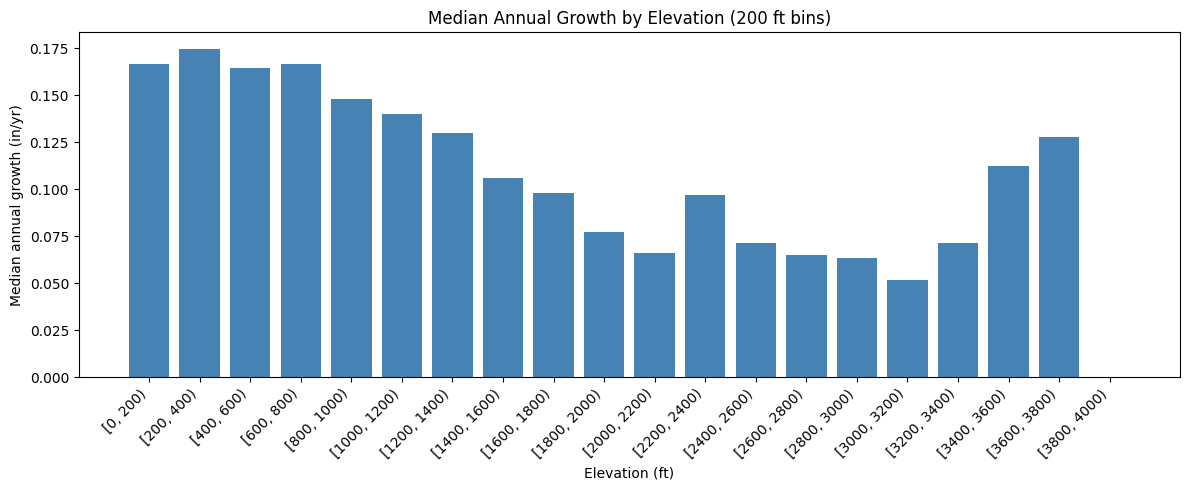


Median growth and record count by elevation bin:
    elev_bin   median  count
    [0, 200) 0.166667 247570
  [200, 400) 0.174603 226900
  [400, 600) 0.164179 165092
  [600, 800) 0.166667  77817
 [800, 1000) 0.147727  42055
[1000, 1200) 0.140000  16099
[1200, 1400) 0.130000   5869
[1400, 1600) 0.106076   1900
[1600, 1800) 0.097826   1019
[1800, 2000) 0.076923    760
[2000, 2200) 0.066120    382
[2200, 2400) 0.097087    185
[2400, 2600) 0.071429    182
[2600, 2800) 0.064897     76
[2800, 3000) 0.063492     37
[3000, 3200) 0.051466     26
[3200, 3400) 0.071429     10
[3400, 3600) 0.112360      2
[3600, 3800) 0.127778      4
[3800, 4000) 0.000000      3


In [25]:
# Bin elevation into 200ft brackets and compute median growth per bin
print(f"Elevation range: {df_growth['ELEV'].min()}–{df_growth['ELEV'].max()} ft")

elev_max = int(df_growth["ELEV"].max()) + 200
df_growth["elev_bin"] = pd.cut(df_growth["ELEV"], bins=range(0, elev_max, 200), right=False)
elev_summary = df_growth.groupby("elev_bin", observed=True)["annual_growth"].agg(["median", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(elev_summary)), elev_summary["median"], color="steelblue", edgecolor="none")
ax.set_xticks(range(len(elev_summary)))
ax.set_xticklabels([str(b) for b in elev_summary["elev_bin"]], rotation=45, ha="right")
ax.set_title("Median Annual Growth by Elevation (200 ft bins)")
ax.set_xlabel("Elevation (ft)")
ax.set_ylabel("Median annual growth (in/yr)")
plt.tight_layout()
plt.show()

print("\nMedian growth and record count by elevation bin:")
print(elev_summary.to_string(index=False))

## 9. Variance Decomposition & ICC

The **Intraclass Correlation Coefficient (ICC)** measures what fraction of total growth variance is explained by which plot (site) a tree is in. A high ICC means plots differ substantially from each other — which matters for experimental design: any field trial must account for this clustering or risk underestimating uncertainty.

We model: `annual_growth ~ 1 + (1 | PLT_CN)` — a random intercept per plot visit, no fixed predictors. The variance components from this model feed directly into the power analysis in Notebook 2.

In [26]:
import statsmodels.formula.api as smf

print(f"Fitting mixed model on {len(df_growth):,} rows x {df_growth['PLT_CN'].nunique():,} unique plots...")
print("(This may take a minute)")

model = smf.mixedlm("annual_growth ~ 1", df_growth, groups=df_growth["PLT_CN"])
result = model.fit(reml=True)

var_between = result.cov_re.iloc[0, 0]   # between-plot variance (random intercept)
var_within  = result.scale               # within-plot variance (residual)
icc = var_between / (var_between + var_within)

print(f"\nVariance components:")
print(f"  Between-plot (site) variance: {var_between:.6f}")
print(f"  Within-plot  (tree) variance: {var_within:.6f}")
print(f"\nICC = {icc:.4f}  ({icc*100:.1f}% of variance is at the plot level)")

Fitting mixed model on 785,988 rows x 65,513 unique plots...
(This may take a minute)

Variance components:
  Between-plot (site) variance: 0.021542
  Within-plot  (tree) variance: 0.013039

ICC = 0.6229  (62.3% of variance is at the plot level)


## 10. Save Variance Parameters

In [27]:
import json, os

variance_params = {
    "var_between": var_between,
    "var_within": var_within,
    "icc": icc,
    "mean_growth": float(df_growth["annual_growth"].mean()),
    "n_rows": len(df_growth),
    "n_plots": df_growth["PLT_CN"].nunique(),
    "notes": "Fit on annual_growth ~ 1 + (1|PLT_CN) via REML. var_between=between-plot, var_within=within-plot (residual)."
}

out_path = os.path.join(OUTPUTS_DIR, "variance_params.json")
with open(out_path, "w") as f:
    json.dump(variance_params, f, indent=2)

print(f"Saved to {out_path}")
print(json.dumps(variance_params, indent=2))

Saved to ../outputs/variance_params.json
{
  "var_between": 0.02154164270791428,
  "var_within": 0.013039196356681366,
  "icc": 0.6229358017506557,
  "mean_growth": 0.1881593581168509,
  "n_rows": 785988,
  "n_plots": 65513,
  "notes": "Fit on annual_growth ~ 1 + (1|PLT_CN) via REML. var_between=between-plot, var_within=within-plot (residual)."
}
